30/3/26

AN AUTOMATED MACHINE LEARNING FRAMEWORK FOR CANCER CELL CLASSIFICATION

In [1]:
# loading datasets
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [2]:
import pandas as pd
from pycaret.classification import setup

# 1. Combine features (X) and target (y) into a single DataFrame
df = pd.concat([X, y], axis=1)

# Check the exact name of your target column
target_col = y.columns[0]

# 2. Initialize the PyCaret environment
clf_setup = setup(
    data=df,
    target=target_col,
    normalize=True,
    normalize_method='zscore',
    fix_imbalance=True,
    train_size=0.75,
    session_id=123,
    verbose=True
)


,Description,Value
0,Session id,123
1,Target,Diagnosis
2,Target type,Binary
3,Target mapping,"B: 0, M: 1"
4,Original data shape,"(569, 31)"
5,Transformed data shape,"(677, 31)"
6,Transformed train set shape,"(534, 31)"
7,Transformed test set shape,"(143, 31)"
8,Numeric features,30
9,Preprocess,True


### Phase 3: Intelligent Model Orchestration

In [ ]:
from pycaret.classification import compare_models, tune_model, pull, predict_model

# 1. Compare all available models to find the top performers
# Sorting by 'Recall' to minimize False Negatives, as per Chapter 3.6
best_models = compare_models(n_select=3, sort='Recall')

# Display the leaderboard for comparison
print("Top 3 Models based on Recall:\n", pull())

# 2. Automatically tune the absolute best model
# PyCaret defaults to picking the first model in the list for tuning
best_model = best_models[0]
tuned_best_model = tune_model(best_model, optimize='Recall')


# 3. Evaluate the tuned model's performance on the 25% unseen hold-out set
predictions = predict_model(tuned_best_model)

# Display prediction results (shows actual vs. predicted label and score)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9812,0.9983,0.9812,0.9825,0.9812,0.9598,0.9612,3.0020
ridge,Ridge Classifier,0.9695,0.9922,0.9695,0.9711,0.9691,0.9333,0.9358,0.0200
lda,Linear Discriminant Analysis,0.9695,0.9895,0.9695,0.9712,0.9691,0.9333,0.9359,0.0250
svm,SVM - Linear Kernel,0.9694,0.9972,0.9694,0.9712,0.9695,0.9354,0.9370,0.0190
ada,Ada Boost Classifier,0.9694,0.9919,0.9694,0.9701,0.9693,0.9343,0.9353,0.0750
et,Extra Trees Classifier,0.9693,0.9950,0.9693,0.9704,0.9692,0.9341,0.9354,0.1110
lightgbm,Light Gradient Boosting Machine,0.9647,0.9924,0.9647,0.9659,0.9646,0.9242,0.9257,0.1870
rf,Random Forest Classifier,0.9623,0.9894,0.9623,0.9643,0.9624,0.9203,0.9220,0.0890
knn,K Neighbors Classifier,0.9622,0.9868,0.9622,0.9631,0.9620,0.9186,0.9200,0.4980
qda,Quadratic Discriminant Analysis,0.9599,0.9880,0.9599,0.9615,0.9599,0.9147,0.9162,0.0190


Top 3 Models based on Recall:
                                     Model  Accuracy     AUC  Recall   Prec.  \
lr                    Logistic Regression    0.9812  0.9983  0.9812  0.9825   
ridge                    Ridge Classifier    0.9695  0.9922  0.9695  0.9711   
lda          Linear Discriminant Analysis    0.9695  0.9895  0.9695  0.9712   
svm                   SVM - Linear Kernel    0.9694  0.9972  0.9694  0.9712   
ada                  Ada Boost Classifier    0.9694  0.9919  0.9694  0.9701   
et                 Extra Trees Classifier    0.9693  0.9950  0.9693  0.9704   
lightgbm  Light Gradient Boosting Machine    0.9647  0.9924  0.9647  0.9659   
rf               Random Forest Classifier    0.9623  0.9894  0.9623  0.9643   
knn                K Neighbors Classifier    0.9622  0.9868  0.9622  0.9631   
qda       Quadratic Discriminant Analysis    0.9599  0.9880  0.9599  0.9615   
gbc          Gradient Boosting Classifier    0.9551  0.9889  0.9551  0.9564   
nb                   

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,0.9767,0.9977,0.9767,0.9781,0.9769,0.9509,0.9520
2,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9767,0.9977,0.9767,0.9776,0.9766,0.9496,0.9508
5,0.9767,0.9977,0.9767,0.9776,0.9766,0.9496,0.9508
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.9524,0.9856,0.9524,0.9558,0.9517,0.8966,0.9014
8,0.9762,0.9856,0.9762,0.9771,0.9760,0.9489,0.9501


Fitting 10 folds for each of 10 candidates, totalling 100 fits


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9650,0.9872,0.9650,0.9653,0.9651,0.9253,0.9254


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis,prediction_label,prediction_score
257,15.320000,17.270000,103.199997,713.299988,0.13350,0.22840,0.24480,0.12420,0.2398,0.07596,...,928.799988,0.17650,0.45030,0.44290,0.22290,0.3258,0.11910,M,M,0.9842
382,12.050000,22.719999,78.750000,447.799988,0.06935,0.10730,0.07943,0.02978,0.1203,0.06659,...,488.399994,0.08799,0.32140,0.29120,0.10920,0.2191,0.09349,B,B,0.9819
241,12.420000,15.040000,78.610001,476.500000,0.07926,0.03393,0.01053,0.01108,0.1546,0.05754,...,543.400024,0.10370,0.07776,0.06243,0.04052,0.2901,0.06783,B,B,0.9962
527,12.340000,12.270000,78.940002,468.500000,0.09003,0.06307,0.02958,0.02647,0.1689,0.05808,...,564.900024,0.12920,0.20740,0.17910,0.10700,0.3110,0.07592,B,B,0.9818
368,21.709999,17.250000,140.899994,1546.000000,0.09384,0.08562,0.11680,0.08465,0.1717,0.05054,...,3143.000000,0.13630,0.16280,0.28610,0.18200,0.2510,0.06494,M,M,0.9999


In [3]:
xdsada

NameError: name 'xdsada' is not defined

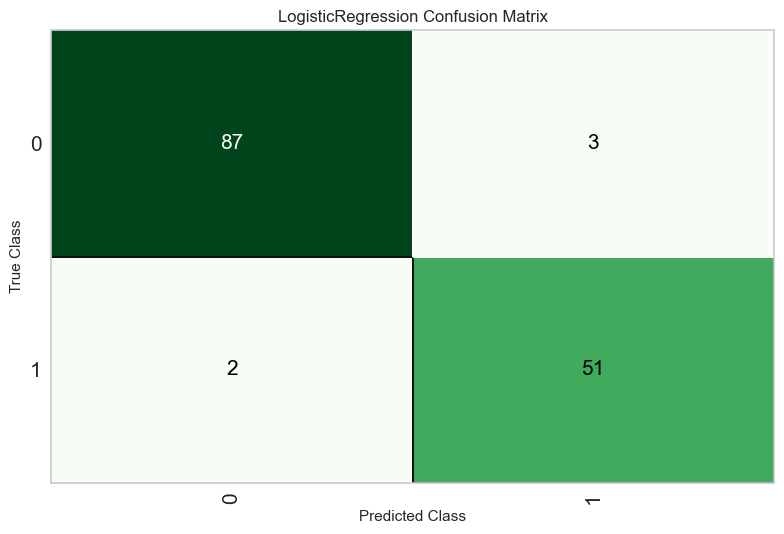

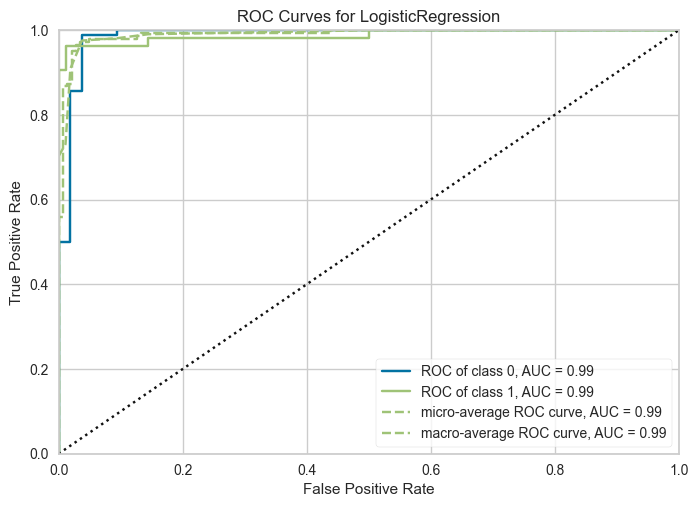

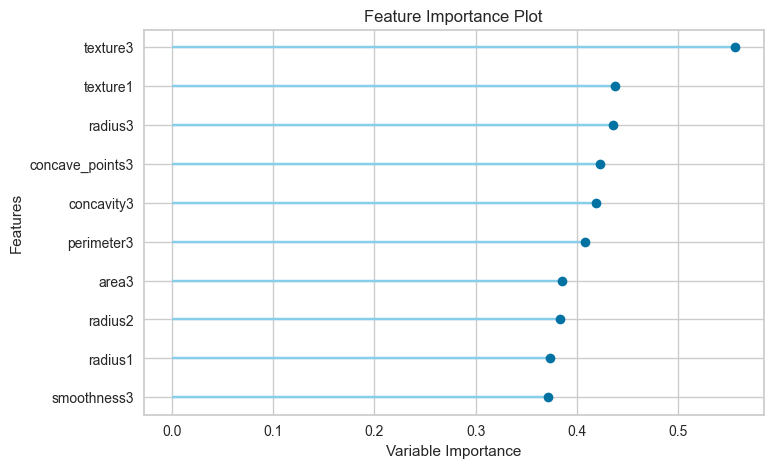

SHAP interpretation skipped for linear model. Rely on the feature importance plot. Error: This function only supports tree based models for binary classification: lightgbm, rf, et, dt.


In [6]:
from pycaret.classification import plot_model, interpret_model

# 1. Plot the Confusion Matrix
# This is the most critical plot for Chapter 3.6. You want to look at the bottom-left 
# quadrant to ensure the False Negatives (predicting Benign when it's actually Malignant) are minimal.
plot_model(tuned_best_model, plot='confusion_matrix')

# 2. Plot the ROC-AUC Curve
# This visualizes the trade-off between the true positive rate and false positive rate.
plot_model(tuned_best_model, plot='auc')

# 3. Plot Feature Importance
# This shows exactly which features (e.g., cell radius, texture) the Logistic Regression 
# model weighed the most when making its decisions.
plot_model(tuned_best_model, plot='feature')

# 4. SHAP Interpretability (Optional but recommended for your thesis)
# Note: SHAP is deeply integrated into PyCaret, but it is primarily optimized for 
# tree-based models (like Random Forest or XGBoost). Since a linear model (LR) won, 
# you can try running this, but if it throws a library error, rely on the 'feature' plot above.
try:
    interpret_model(tuned_best_model)
except Exception as e:
    print(f"SHAP interpretation skipped for linear model. Rely on the feature importance plot. Error: {e}")

In [ ]:
from pycaret.classification import finalize_model, save_model

# 1. Finalize the model
# This trains your tuned Logistic Regression model on the ENTIRE dataset 
# (including the 25% hold-out set) so it has maximum knowledge before deployment.
final_lr_model = finalize_model(tuned_best_model)

print("Model finalized successfully!")

# 2. Serialize and save the model
# This exports the entire pipeline (data scaling, SMOTE handling, and the LR model)
# into a single, lightweight .pkl file.
save_model(final_lr_model, 'cancer_classification_pipeline')

print("Model saved as 'cancer_classification_pipeline.pkl'")

Model finalized successfully!
Transformation Pipeline and Model Successfully Saved
Model saved as 'cancer_classification_pipeline.pkl'
